## 2. 导入库与生成数据（继续使用带10%噪声的数据）

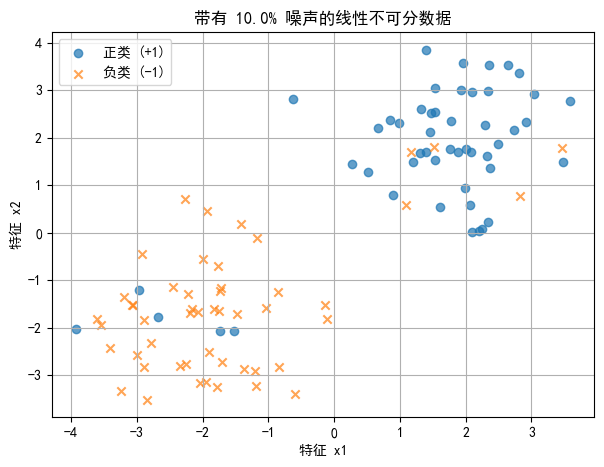

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

# 固定随机种子
np.random.seed(42)

# --- 生成两类数据（中心在 (2,2) 和 (-2,-2)）---
X1 = np.random.randn(50, 2) + np.array([2, 2])
y1 = np.ones(50)
X2 = np.random.randn(50, 2) + np.array([-2, -2])
y2 = -np.ones(50)

X = np.vstack([X1, X2])
y = np.hstack([y1, y2])

# --- 引入 10% 标签噪声（让数据线性不可分）---
noise_ratio = 0.1
n_samples = len(y)
n_noise = int(noise_ratio * n_samples)
noise_idx = np.random.choice(n_samples, n_noise, replace=False)
y[noise_idx] = -y[noise_idx]  # 翻转标签

# 可视化
plt.figure(figsize=(7, 5))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='正类 (+1)', marker='o', alpha=0.7)
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], label='负类 (-1)', marker='x', alpha=0.7)
plt.title(f'带有 {noise_ratio*100}% 噪声的线性不可分数据')
plt.xlabel('特征 x1')
plt.ylabel('特征 x2')
plt.legend()
plt.grid(True)
plt.show()

## 3. 核心数学公式

对于样本 $ (x_i, y_i) $，其中 $ y_i \in \{+1, -1\} $，线性 SVM 的无约束损失函数（即目标函数）如下：

$$
L(w, b) = \frac{1}{2} \|w\|^2 + C \sum_{i=1}^m \max(0, 1 - y_i(w \cdot x_i + b))
$$

这个公式由两项构成，下面逐项拆解：

---

### 1). 第一项（正则项）：$ \frac{1}{2} \|w\|^2 $
- **作用**：这是**间隔最大化**的直接体现。
- **几何含义**：在 SVM 中，决策边界（超平面）到最近样本点的距离称为“几何间隔”，其大小等于 $ \frac{2}{\|w\|} $。因此，**最小化 $ \|w\| $ 等价于最大化间隔**。
- **数学保证**：这一项是严格凸的（二次函数），它为整个损失函数提供了**强凸性**，从而保证了模型解的**唯一性**（这是感知机完全不具备的性质）。
- **直观理解**：它让模型倾向于寻找一条“宽阔”的马路，而不是紧贴着数据点过去。

---

### 2). 第二项（合页损失 / Hinge Loss）：$ C \sum_{i=1}^m \max(0, 1 - y_i f(x_i)) $
其中 $ f(x_i) = w \cdot x_i + b $，合页损失 $ \max(0, 1 - y_i f(x_i)) $ 是一个分段函数：

- **当 $ y_i f(x_i) \geq 1 $**（样本被正确分类且远离边界，确信度足够高）：
  $$
  \max(0, 1 - y_i f(x_i)) = 0
  $$
  此时该样本**不产生任何损失**，模型不会因它而调整参数。这正是“**仅支持向量影响模型**”的根本原因。

- **当 $ y_i f(x_i) < 1 $**（样本被误分类，或虽分类正确但落在边界带内）：
  $$
  \max(0, 1 - y_i f(x_i)) = 1 - y_i f(x_i) > 0
  $$
  此时损失随“错误程度”或“离边界的距离”**线性增加**（注意是线性，而不是交叉熵的指数级）。因此 SVM 对噪声点相对不那么敏感。

- **为什么叫“合页”**：因为函数图像像一个折起来的书页（hinge），在 $ y_i f(x_i) = 1 $ 处有一个不可导的拐点。

---

### 3). 超参数 $ C $ (惩罚参数)：平衡“宽度”与“容错”
- **作用**：控制第一项（最大化间隔）和第二项（最小化训练误差）之间的**权衡系数**。
- **$ C $ 很大**：模型会尽全力减少合页损失，即使这意味着牺牲间隔宽度（即 $ \|w\| $ 变大）。这容易**过拟合**，因为模型会极力把每个点都正确分类，包括噪声点。
- **$ C $ 很小**：模型更倾向于让马路更宽（即 $ \|w\| $ 更小），哪怕因此允许个别点踩线或误分类。这会提高模型的**泛化能力**，但可能导致在训练集上表现稍差。
- **注意**：$ C $ 可以理解为“正则化强度的倒数”——$ C $ 越大，正则化越弱，模型复杂度越高。

---

## 次梯度更新（我们使用最简单的随机梯度下降法 SGD）

由于合页损失在 $ y_i f(x_i) = 1 $ 处不可导，我们使用**次梯度（subgradient）**来代替梯度进行参数更新。

对 $ w $ 求次梯度，分两种情况：

#### 情况一：安全区（$ y_i (w \cdot x_i + b) \geq 1 $）
此时合页损失为 0，梯度仅来自正则项：
$$
\nabla_w = w
$$
更新规则为：
$$
w \leftarrow w - \eta \cdot w = (1 - \eta) \cdot w
$$
- 这看起来像**权重衰减**（weight decay），实际上就是 L2 正则化的体现。
- 每一次更新都在**主动地压缩 $ w $ 的模长**，从而自然地保持间隔最大化。

#### 情况二：误分类或在边界带内（$ y_i (w \cdot x_i + b) < 1 $）
此时合页损失贡献为 $ 1 - y_i (w \cdot x_i + b) $，它对 $ w $ 的梯度为 $ -y_i x_i $。总次梯度为：
$$
\nabla_w = w - C \cdot y_i \cdot x_i
$$
更新规则为：
$$
w \leftarrow w - \eta \cdot (w - C \cdot y_i \cdot x_i) = (1 - \eta) \cdot w + \eta \cdot C \cdot y_i \cdot x_i
$$

对偏置 $ b $ 的次梯度为：
- 安全区：$ \nabla_b = 0 $
- 非安全区：$ \nabla_b = -C \cdot y_i $
更新规则为：
$$
b \leftarrow b - \eta \cdot (-C \cdot y_i) = b + \eta \cdot C \cdot y_i
$$

---

### 🔥 SVM 代码最精妙的地方：与感知机的本质区别

- **感知机**：更新规则为 $ w \leftarrow w + \eta \cdot y_i \cdot x_i $（仅当误分类时）。它没有正则项，参数会不断累积，不会自然收敛到一个稳定的值（解不唯一）。
- **SVM（SGD 版）**：更新规则为：
  - 误分类或边界内：$ w \leftarrow (1 - \eta) \cdot w + \eta \cdot C \cdot y_i \cdot x_i $
  - 安全区：$ w \leftarrow (1 - \eta) \cdot w $

  即使在安全区（没有误分类），SVM 依然在**主动衰减权重**（$ (1 - \eta) \cdot w $），驱动 $ w $ 向更小的值移动，从而**自动追求间隔最大化**。

> **结论**：SVM 在更新时永远带着 $ w $（正则项），因此参数会自然收敛到唯一的全局最优解，而不会像感知机那样在不同初始化下得到不同的超平面。这正是 SVM 被称为线性判别模型“终极答案”的根本原因。

## 4. 从零实现线性SVM（封装成类）

In [3]:
class LinearSVM:
    """使用随机次梯度下降的线性SVM（软间隔）"""

    def __init__(self, C=1.0, learning_rate=0.001, max_epochs=1000, tol=1e-5):
        self.C = C                # 惩罚系数
        self.lr = learning_rate   # 学习率（SVM需较小学习率）
        self.max_epochs = max_epochs
        self.tol = tol            # 早停阈值

        self.w = None
        self.b = None
        self.loss_history = []
        self.support_vectors_ = None   # 记录支持向量索引

    def _compute_loss(self, X, y):
        """计算当前参数下的总损失（用于监控训练）"""
        m = X.shape[0]
        margins = y * (np.dot(X, self.w) + self.b)
        # 合页损失: max(0, 1 - margin)
        hinge_loss = np.maximum(0, 1 - margins)
        # L2正则项 + C * 合页损失之和
        loss = 0.5 * np.dot(self.w, self.w) + self.C * np.sum(hinge_loss)
        return loss

    def fit(self, X, y):
        """
        训练线性SVM
        X: shape (m, n)
        y: 取值 +1 或 -1
        """
        m, n = X.shape
        # 初始化参数为0
        self.w = np.zeros(n)
        self.b = 0.0
        self.loss_history = []

        for epoch in range(self.max_epochs):
            # 随机打乱样本顺序（加速收敛，且不影响最终唯一解）
            indices = np.random.permutation(m)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            # 遍历每个样本进行更新
            for i in range(m):
                xi = X_shuffled[i]
                yi = y_shuffled[i]

                # 计算当前样本的函数间隔
                margin = yi * (np.dot(xi, self.w) + self.b)

                # --- 次梯度判断 ---
                if margin >= 1:
                    # 情况1：分类正确且在安全区（间隔带外），只施加 L2 正则梯度
                    dw = self.w
                    db = 0
                else:
                    # 情况2：分类错误 或 在间隔带内部（0~1之间），施加合页损失梯度
                    dw = self.w - self.C * yi * xi
                    db = - self.C * yi

                # 参数更新（沿负梯度方向）
                self.w -= self.lr * dw
                self.b -= self.lr * db

            # 每轮结束后记录损失
            loss = self._compute_loss(X, y)
            self.loss_history.append(loss)

            # 早停机制（损失变化极小就停止）
            if epoch > 0 and abs(self.loss_history[-1] - self.loss_history[-2]) < self.tol:
                print(f"✅ 在第 {epoch+1} 轮收敛（损失变化 < {self.tol}）")
                break

        # 记录哪些点是支持向量（近似）：即函数间隔绝对值 <= 1 的点
        margins_all = y * (np.dot(X, self.w) + self.b)
        self.support_vectors_ = np.where(np.abs(margins_all) <= 1.0)[0]

        print(f"🏁 训练完成，共迭代 {len(self.loss_history)} 轮")
        print(f"📉 最终损失: {self.loss_history[-1]:.4f}")
        print(f"⭐ 支持向量数量: {len(self.support_vectors_)} / {m}")

    def decision_function(self, X):
        """返回决策函数值 w·x + b（距离）"""
        return np.dot(X, self.w) + self.b

    def predict(self, X):
        """预测类别 +1 或 -1"""
        return np.sign(self.decision_function(X))

    def score(self, X, y):
        """计算分类准确率"""
        pred = self.predict(X)
        return np.mean(pred == y)

## 5. 训练模型并观察效果
#### 注意：SVM对特征尺度敏感，如果数据量级差别大，需要标准化。这里我们的数据量级接近，直接训练。

In [4]:
# 创建模型实例（C=1.0 是比较中庸的选择）
model_svm = LinearSVM(C=1.0, learning_rate=0.001, max_epochs=800)

# 训练
model_svm.fit(X, y)

# 准确率
acc = model_svm.score(X, y)
print(f"🎯 训练集准确率: {acc * 100:.2f}%")

🏁 训练完成，共迭代 800 轮
📉 最终损失: 31.6305
⭐ 支持向量数量: 42 / 100
🎯 训练集准确率: 90.00%


## 6. 绘制损失下降曲线

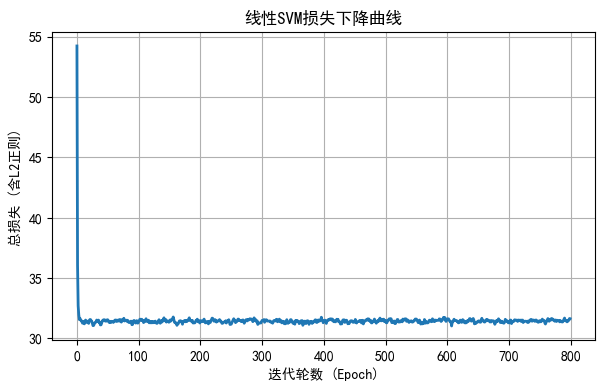

In [5]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(model_svm.loss_history)), model_svm.loss_history, linewidth=2)
plt.xlabel('迭代轮数 (Epoch)')
plt.ylabel('总损失 (含L2正则)')
plt.title('线性SVM损失下降曲线')
plt.grid(True)
plt.show()

## 7. 🎨 可视化决策边界与“支持向量”（SVM的灵魂）
#### 这一步极其关键！红色实线是决策面，蓝色虚线是间隔边界（距离为1）。落在蓝色虚线或以内的点（绿圈标出）就是支撑起整个分类平面的“支持向量”。

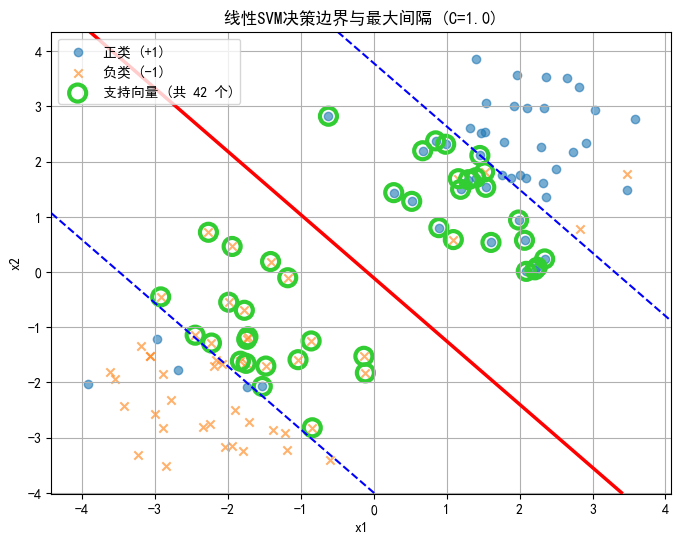

In [6]:
# 绘制原始数据
plt.figure(figsize=(8, 6))
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], label='正类 (+1)', marker='o', alpha=0.6)
plt.scatter(X[y==-1][:, 0], X[y==-1][:, 1], label='负类 (-1)', marker='x', alpha=0.6)

# 生成网格点
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# 计算决策函数值
Z = model_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制三条关键线：决策面 (0) 和 间隔边界 (±1)
plt.contour(xx, yy, Z, levels=[-1, 0, 1],
            colors=['blue', 'red', 'blue'],
            linestyles=['--', '-', '--'],
            linewidths=[1.5, 2.5, 1.5])

# 高亮显示支持向量（绿圈）
sv_indices = model_svm.support_vectors_
plt.scatter(X[sv_indices][:, 0], X[sv_indices][:, 1],
            s=150, facecolors='none', edgecolors='limegreen', linewidths=3,
            label=f'支持向量 (共 {len(sv_indices)} 个)')

plt.title('线性SVM决策边界与最大间隔 (C=1.0)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True)
plt.show()

## 8. 🧪 超参数 C 的影响力实验（调参基本功）
#### 调大 C（如 100），模型会拼命把所有点（包括噪声）都正确分类，边界会变得复杂，容易过拟合。调小 C（如 0.01），模型会优先保证“马路宽度”，牺牲一些噪声点的准确率。

In [7]:
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
print("C值\t\t准确率\t\t支持向量数")
print("-" * 45)

for C in C_values:
    model = LinearSVM(C=C, learning_rate=0.001, max_epochs=500)
    model.fit(X, y)
    acc = model.score(X, y)
    sv_num = len(model.support_vectors_)
    print(f"C = {C:6.2f}\t\t{acc:.3f}\t\t{sv_num:3d} 个")

C值		准确率		支持向量数
---------------------------------------------
✅ 在第 57 轮收敛（损失变化 < 1e-05）
🏁 训练完成，共迭代 57 轮
📉 最终损失: 0.9523
⭐ 支持向量数量: 100 / 100
C =   0.01		0.900		100 个
🏁 训练完成，共迭代 500 轮
📉 最终损失: 5.2340
⭐ 支持向量数量: 100 / 100
C =   0.10		0.900		100 个
🏁 训练完成，共迭代 500 轮
📉 最终损失: 31.3163
⭐ 支持向量数量: 40 / 100
C =   1.00		0.900		 40 个
🏁 训练完成，共迭代 500 轮
📉 最终损失: 295.2145
⭐ 支持向量数量: 27 / 100
C =  10.00		0.900		 27 个
🏁 训练完成，共迭代 500 轮
📉 最终损失: 3558.5209
⭐ 支持向量数量: 6 / 100
C = 100.00		0.900		  6 个


## 9. ✅ 与 Sklearn 官方实现对比

In [8]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler

# Sklearn建议对数据做标准化，这里为了公平对比，我们直接训练（我们的数据量级一致）
sk_model = LinearSVC(C=1.0, max_iter=1000, random_state=42, dual=False)
sk_model.fit(X, y)

print(f"Sklearn 准确率: {sk_model.score(X, y):.3f}")
print(f"Sklearn 权重 w: {sk_model.coef_.flatten()}")
print(f"我们的权重 w: {model_svm.w}")

Sklearn 准确率: 0.900
Sklearn 权重 w: [0.14239668 0.24448867]
我们的权重 w: [0.29448267 0.25709524]
